# 04 Climate-Macro Integrated Assessment: A DICE-Inspired Laboratory

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/10-Specialized-Models/04_Climate_Macro_Integrated_Assessment_DICE.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=10-Specialized-Models/04_Climate_Macro_Integrated_Assessment_DICE.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)
## The Lens: Pricing a Stock Externality Across Centuries
Climate policy is a dynamic control problem with unusually long delays. Emissions today add to an atmospheric stock; the stock changes radiative forcing; temperature responds gradually; damages affect output; and mitigation diverts resources today to reduce future losses. Integrated assessment models (IAMs) make those links explicit so assumptions about growth, discounting, climate persistence, damages, and abatement can be stress-tested in one coherent system.

This notebook builds a deliberately simplified **DICE-inspired** model rather than claiming to reproduce an official DICE release. The simplification is pedagogical: one carbon reservoir and one temperature state replace the multi-box climate module, while output, damages, abatement costs, and discounted utility preserve the feedback structure. We optimize a low-dimensional abatement ramp, compare climate and consumption paths with a no-policy baseline, and compute a local present-value damage increment from an additional unit of emissions. The main lesson is not a single carbon price; it is how the price changes when discounting, damages, carbon persistence, or the policy-control parameterization changes.

### Learning Objectives
- **Map** emissions, carbon stock, temperature, damages, output, and welfare into a dynamic system.
- **Simulate** a transparent DICE-inspired economy-climate model.
- **Optimize** a constrained abatement path and interpret the shadow trade-off.
- **Stress-test** the implied carbon-cost proxy under alternative discounting and damage assumptions.

### Prerequisites
- `../04-Macro-Models/02_Neoclassical_Growth.ipynb`: growth dynamics and intertemporal welfare.
- `../02-Numerical-Methods/05_Optimization.ipynb`: constrained nonlinear optimization.
- `03_Network_Economics.ipynb`: dynamic externalities and propagation intuition.

> **Historical Context — Nordhaus builds DICE (1992).** William Nordhaus's Dynamic Integrated Climate-Economy model (Science, 1992) coupled a Ramsey growth model to a carbon cycle, giving the social cost of carbon its first computable home — decades before carbon pricing entered law. The 2018 Nobel recognized the synthesis.

> **Learning path:** Building on [`03_Network_Economics.ipynb`](03_Network_Economics.ipynb); this notebook closes the current track.


## Table of Contents

1. [A compact economy-climate system](#economy-climate)
2. [Simulation engine](#simulation-engine)
3. [Policy parameterization](#policy-parameterization)
4. [Optimal abatement experiment](#optimal-abatement)
5. [Marginal emissions damage](#marginal-damage)
6. [Sensitivity and exercises](#sensitivity)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "figure.figsize": (10, 6), "figure.dpi": 120})
np.set_printoptions(suppress=True, precision=5, linewidth=120)

from scipy.optimize import minimize


<a id="economy-climate"></a>
## 1. A Compact Economy-Climate System

Potential output grows exogenously,

$$Y_{t+1}^{pot}=Y_t^{pot}(1+g),$$

baseline industrial emissions are proportional to output, and control $\mu_t\in[0,1]$ abates a fraction:

$$E_t=\sigma_tY_t^{pot}(1-\mu_t).$$

A one-box atmospheric carbon stock follows

$$M_{t+1}=M_{pre}+\phi_M(M_t-M_{pre})+\chi E_t,$$

and temperature evolves toward logarithmic forcing,

$$T_{t+1}=\phi_TT_t+\xi_T\frac{\log(M_t/M_{pre})}{\log 2}.$$

Output losses combine quadratic climate damages $d_2T_t^2$ and convex abatement costs $\theta\mu_t^\psi$. Consumption is positive net output and welfare is the discounted sum of log consumption.


<a id="simulation-engine"></a>
## 2. Simulation Engine

Parameter values below are illustrative and internally consistent, not a calibration to any official DICE vintage. That distinction matters: an IAM's numerical carbon price is only as credible as its calibrated climate and economic blocks.


In [2]:
def simulate_iam(
    control,
    periods=40,
    years_per_period=5,
    growth=0.012,
    emissions_intensity=0.32,
    intensity_decline=0.01,
    carbon_persistence=0.985,
    emissions_to_carbon=0.12,
    temp_persistence=0.88,
    climate_response=0.24,
    damage_quad=0.0025,
    abatement_scale=0.03,
    abatement_power=2.6,
    pure_time_preference=0.015,
    initial_output=100.0,
    initial_carbon=890.0,
    preindustrial_carbon=588.0,
    initial_temp=1.2,
    emissions_pulse=0.0,
):
    """Simulate a transparent one-box DICE-inspired economy-climate model."""
    control = np.clip(np.asarray(control, dtype=float), 0.0, 1.0)
    if control.size != periods:
        raise ValueError("Control path length must equal periods.")
    if min(initial_output, initial_carbon, preindustrial_carbon) <= 0:
        raise ValueError("Output and carbon stocks must be positive.")

    output_potential = np.empty(periods)
    carbon = np.empty(periods)
    temperature = np.empty(periods)
    emissions = np.empty(periods)
    consumption = np.empty(periods)
    damages = np.empty(periods)
    abatement_cost = np.empty(periods)
    output_potential[0], carbon[0], temperature[0] = initial_output, initial_carbon, initial_temp

    for t in range(periods):
        if t > 0:
            output_potential[t] = output_potential[t - 1] * (1 + growth) ** years_per_period
        sigma_t = emissions_intensity * (1 - intensity_decline) ** (t * years_per_period)
        emissions[t] = sigma_t * output_potential[t] * (1 - control[t])
        if t == 0:
            emissions[t] += emissions_pulse

        damage_share = damage_quad * temperature[t] ** 2
        abatement_share = abatement_scale * control[t] ** abatement_power
        damages[t] = output_potential[t] * damage_share
        abatement_cost[t] = output_potential[t] * abatement_share
        consumption[t] = output_potential[t] - damages[t] - abatement_cost[t]
        if consumption[t] <= 0:
            raise ValueError("Calibration produced non-positive consumption.")

        if t + 1 < periods:
            carbon[t + 1] = preindustrial_carbon + carbon_persistence * (carbon[t] - preindustrial_carbon) + emissions_to_carbon * emissions[t]
            forcing = np.log(max(carbon[t], 1e-9) / preindustrial_carbon) / np.log(2)
            temperature[t + 1] = temp_persistence * temperature[t] + climate_response * forcing

    beta = np.exp(-pure_time_preference * years_per_period)
    discount = beta ** np.arange(periods)
    welfare = float(np.sum(discount * np.log(consumption)))
    pv_damages = float(np.sum(discount * damages))
    return pd.DataFrame({
        "output_potential": output_potential,
        "emissions": emissions,
        "carbon": carbon,
        "temperature": temperature,
        "damages": damages,
        "abatement_cost": abatement_cost,
        "consumption": consumption,
        "control": control,
        "discount": discount,
    }), welfare, pv_damages

baseline_control = np.zeros(40)
baseline, baseline_welfare, baseline_pv_damages = simulate_iam(baseline_control)
baseline.tail(3)


,output_potential,emissions,carbon,temperature,damages,abatement_cost,consumption,control,discount
37,908.646197,45.295577,893.248361,1.192047,3.227909,0.0,905.418288,0.0,0.062349
38,964.489215,45.722959,894.105104,1.193780,3.436259,0.0,961.052956,0.0,0.057844
39,1023.764199,46.154374,895.000283,1.195637,3.658800,0.0,1020.105399,0.0,0.053665


<a id="policy-parameterization"></a>
## 3. Policy Parameterization

Optimizing one control for every period can hide non-identification behind a high-dimensional optimizer. We start with a two-parameter ramp,

$$\mu_t=\mathrm{clip}(\mu_0+s\,t,0,1),$$

which makes the policy experiment interpretable. A later extension can optimize a spline or direct-control vector once this baseline is verified.


In [3]:
def ramp_control(params, periods=40):
    mu0, slope = params
    return np.clip(mu0 + slope * np.arange(periods), 0.0, 1.0)


def welfare_objective(params):
    control = ramp_control(params)
    _, welfare, _ = simulate_iam(control)
    return -welfare

opt = minimize(
    welfare_objective,
    x0=np.array([0.05, 0.02]),
    bounds=[(0.0, 1.0), (0.0, 0.10)],
    method="L-BFGS-B",
)
if not opt.success:
    raise RuntimeError(opt.message)
optimal_control = ramp_control(opt.x)
policy, policy_welfare, policy_pv_damages = simulate_iam(optimal_control)
print(f"optimal ramp parameters: mu0={opt.x[0]:.3f}, slope={opt.x[1]:.4f}")
print(f"welfare gain over no-policy baseline: {policy_welfare - baseline_welfare:.5f}")


optimal ramp parameters: mu0=0.038, slope=0.0000
welfare gain over no-policy baseline: 0.00013


<a id="optimal-abatement"></a>
## 4. Optimal Abatement Experiment

A welfare-improving path trades current abatement cost against lower future climate damages. The optimization should be interpreted comparatively: changing the pure rate of time preference or damage curvature shifts the path because it changes how future losses are valued.


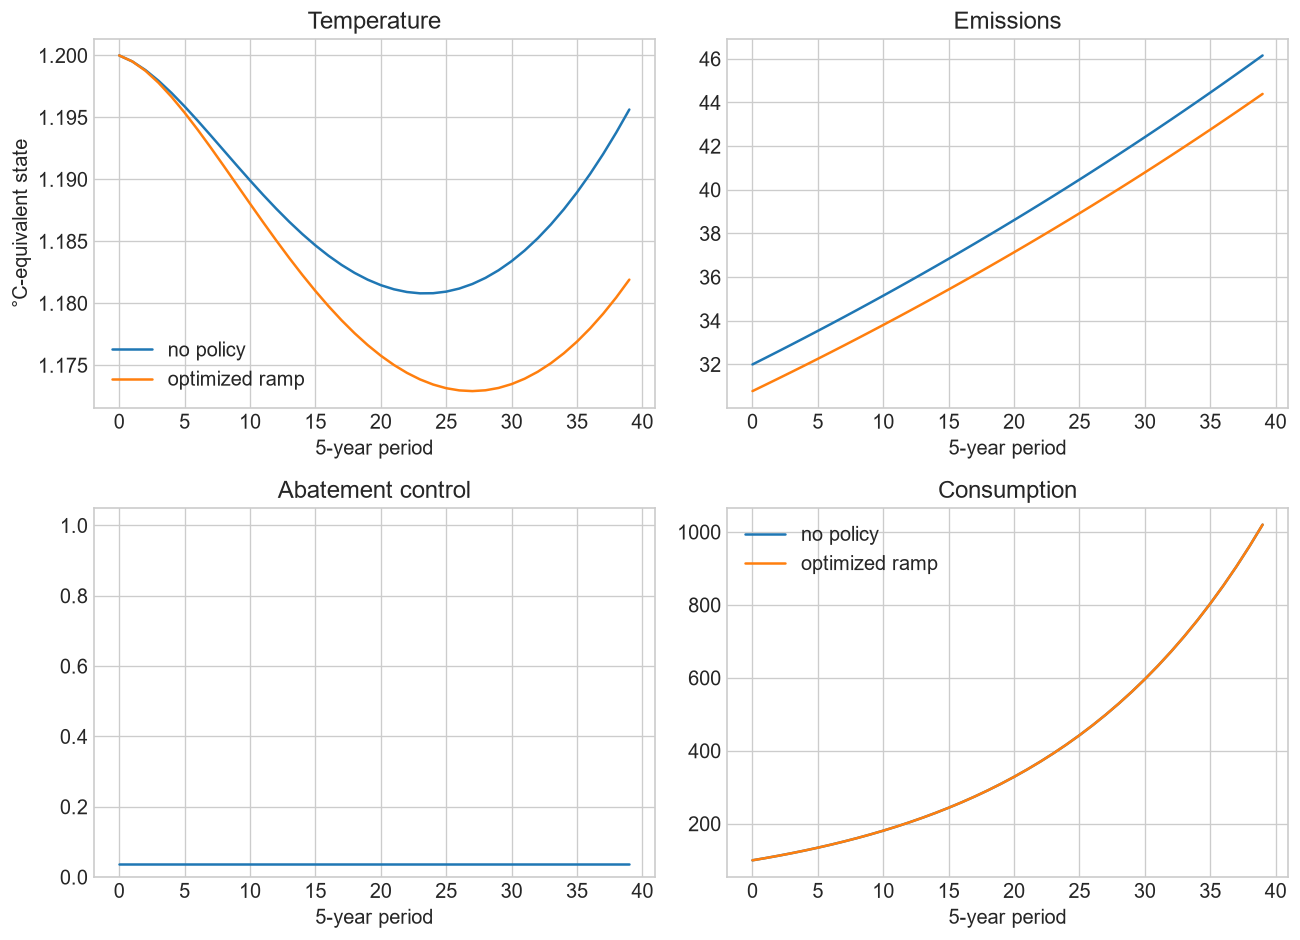

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
axes[0].plot(baseline["temperature"], label="no policy")
axes[0].plot(policy["temperature"], label="optimized ramp")
axes[0].set(title="Temperature", ylabel="°C-equivalent state")
axes[1].plot(baseline["emissions"], label="no policy")
axes[1].plot(policy["emissions"], label="optimized ramp")
axes[1].set(title="Emissions")
axes[2].plot(optimal_control)
axes[2].set(title="Abatement control", ylim=(0, 1.05))
axes[3].plot(baseline["consumption"], label="no policy")
axes[3].plot(policy["consumption"], label="optimized ramp")
axes[3].set(title="Consumption")
for ax in axes: ax.set_xlabel("5-year period")
axes[0].legend(); axes[3].legend()
plt.tight_layout(); plt.show()


<a id="marginal-damage"></a>
## 5. Marginal Emissions Damage

A local carbon-cost diagnostic can be formed by perturbing period-0 emissions by a small amount and measuring the change in discounted model damages:

$$MD_0\approx\frac{PV(D\mid E_0+\Delta E)-PV(D\mid E_0)}{\Delta E}.$$

This is **not** a unit-converted official social cost of carbon. It is a marginal-damage proxy in this model's output/emissions units, useful for sensitivity analysis and for checking that the climate block has the expected sign.


In [5]:
pulse = 0.1
_, _, pv_damage_base = simulate_iam(optimal_control, emissions_pulse=0.0)
_, _, pv_damage_pulse = simulate_iam(optimal_control, emissions_pulse=pulse)
marginal_damage_proxy = (pv_damage_pulse - pv_damage_base) / pulse
print(f"present-value marginal damage proxy = {marginal_damage_proxy:.5f} output units per emissions unit")
assert marginal_damage_proxy > 0


present-value marginal damage proxy = 0.00408 output units per emissions unit


## Key Equations

These relations are collected from the derivations above as a review map. Their assumptions and derivations remain part of the result; this box is not a substitute for them.

**1. Core relation**

$$Y_{t+1}^{pot}=Y_t^{pot}(1+g),$$

**2. Core relation**

$$E_t=\sigma_tY_t^{pot}(1-\mu_t).$$

**3. Core relation**

$$M_{t+1}=M_{pre}+\phi_M(M_t-M_{pre})+\chi E_t,$$

**4. Core relation**

$$T_{t+1}=\phi_TT_t+\xi_T\frac{\log(M_t/M_{pre})}{\log 2}.$$


<a id="sensitivity"></a>
## 6. Exercises and Sensitivity Analysis

**1. Discounting (Conceptual):** Explain why a higher pure rate of time preference generally lowers current abatement in this model. Distinguish the ethical discounting assumption from technological climate persistence.

**2. Damage curvature (Applied):** Re-optimize the ramp for `damage_quad` from 0.001 to 0.008. Plot initial abatement, long-run abatement, peak temperature, and the marginal-damage proxy.

**3. Climate block (Challenge):** Replace the one-box carbon/temperature system with two carbon reservoirs and two thermal boxes. Calibrate only from explicitly cited sources, then compare policy conclusions with the pedagogical one-box model.

**Failure analysis (Challenge):** The computed social cost of carbon is negative in one scenario and the carbon-cycle stocks do not conserve emissions. Diagnose the sign error in damages and the missing mass-balance check, repair both, and verify conservation plus a plausible positive SCC range.

## Economic Interpretation: The carbon price is an intertemporal shadow value

In an integrated assessment model, an additional unit of emissions raises future atmospheric carbon, temperature, and damages while current abatement uses resources today. The social cost of carbon is therefore a shadow value that prices the discounted marginal welfare damage of emissions along the model's transition path. Its magnitude is jointly determined by climate dynamics, damages, preferences, growth, and the assumed policy instrument; it is not a universal physical constant.


## Summary & Key Takeaways

- IAMs couple a stock externality to economic dynamics; delays make intertemporal assumptions central to policy results.
- This notebook is DICE-inspired, not a replication of an official DICE codebase or calibration.
- A low-dimensional policy ramp makes the optimization transparent and easier to stress-test before using richer controls.
- Marginal damage, optimal control, and temperature paths should all be reported with sensitivity to discounting, damages, and climate persistence.


## References & Further Reading

- Nordhaus, W. D. (2017). Revisiting the social cost of carbon. *Proceedings of the National Academy of Sciences*, 114(7), 1518–1523.
- Nordhaus, W. D. & Sztorc, P. (2013). *DICE 2013R: Introduction and User's Manual*.
- Golosov, M., Hassler, J., Krusell, P. & Tsyvinski, A. (2014). Optimal taxes on fossil fuel in general equilibrium. *Econometrica*, 82(1), 41–88.
